In [11]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.runnables import RunnableLambda
from langchain.schema import Document
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
import torch
import os
from dotenv import load_dotenv

from openai import OpenAI

load_dotenv()

True

In [2]:
LEKTURY_FILE = "pan-tadeusz.txt"
CHROMA_DB_DIR = "chroma_db"


In [3]:
# === 2. EMBEDDING MODEL ===

# embedding_model = HuggingFaceEmbeddings(
#     model_name="intfloat/multilingual-e5-small",
#     model_kwargs={
#         "device": "cuda" if torch.cuda.is_available() else "cpu"
#     },
#     encode_kwargs={
#         "normalize_embeddings": True
#     }
# )

# embedding_model = HuggingFaceEmbeddings(
#     model_name="intfloat/multilingual-e5-large-instruct",
#     model_kwargs={
#         "device": "cuda" if torch.cuda.is_available() else "cpu"
#     },
#     encode_kwargs={
#         "normalize_embeddings": True
#     }
# )

embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={
        "device": "cuda" if torch.cuda.is_available() else "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)

# embedding_model = HuggingFaceEmbeddings(
#     model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
#     model_kwargs={
#         "device": "cuda" if torch.cuda.is_available() else "cpu"
#     },
#     encode_kwargs={
#         "normalize_embeddings": True
#     }
# )


In [4]:
# === 3. WCZYTAJ DOKUMENTY I STWÓRZ EMBEDDINGI ===
def load_documents(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    
    # More sophisticated splitting
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,  # Optimal for most embeddings
        chunk_overlap=50,
        separators=["\n\n", "\n", " ", ""]  # Try to keep paragraphs together
    )
    return text_splitter.create_documents([text])


documents = load_documents(LEKTURY_FILE)


# Add source metadata to each document
for i, doc in enumerate(documents):
    doc.metadata = {
        "source": LEKTURY_FILE,
        "chunk_id": i,
        "length": len(doc.page_content)
    }


In [5]:
documents

[Document(metadata={'source': 'pan-tadeusz.txt', 'chunk_id': 0, 'length': 399}, page_content='Adam Mickiewicz\n\nPan Tadeusz\nczyli ostatni zajazd na Litwie\n\nISBN 978-83-288-2495-9\n\n\n\n\n\nKsięga pierwsza\n\n\n\nGospodarstwo\n\nPowrót panicza — Spotkanie się pierwsze w pokoiku, drugie u stołu — Ważna Sędziego nauka o grzeczności — Podkomorzego uwagi polityczne nad modami — Początek sporu o Kusego i Sokoła — Żale Wojskiego — Ostatni Woźny Trybunału — Rzut oka na ówczesny stan polityczny Litwy i Europy'),
 Document(metadata={'source': 'pan-tadeusz.txt', 'chunk_id': 1, 'length': 176}, page_content='Litwo! Ojczyzno moja! ty jesteś jak zdrowie:\nIle cię trzeba cenić, ten tylko się dowie,\nKto cię stracił. Dziś piękność twą w całej ozdobie\nWidzę i opisuję, bo tęsknię po tobie.'),
 Document(metadata={'source': 'pan-tadeusz.txt', 'chunk_id': 2, 'length': 479}, page_content='Panno święta, co Jasnej bronisz Częstochowy\nI w Ostrej świecisz Bramie! Ty, co gród zamkowy\nNowogródzki ochranias

In [5]:
# === 4. TWORZENIE BAZY WEKTOROWEJ ===

vectordb = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    persist_directory=CHROMA_DB_DIR,
    collection_metadata={"hnsw:space": "cosine"}  # Better similarity metric
)

In [6]:
# Check if embeddings worked
print(f"Embedded {len(documents)} chunks")
sample_embedding = vectordb._collection.get(include=["embeddings"])["embeddings"][0]
print(f"Sample embedding length: {len(sample_embedding)}")

Embedded 1269 chunks
Sample embedding length: 1024


In [8]:
sample_embedding


array([-8.01738650e-02,  9.16294977e-02, -7.56772459e-02, -5.26783569e-03,
        5.13692852e-03,  3.62557434e-02,  4.51539867e-02,  1.05120480e-01,
        6.05368055e-02, -3.04776710e-02,  2.82000639e-02,  2.83762850e-02,
        4.03470770e-02, -4.60038967e-02, -1.83000602e-02,  8.26456584e-03,
       -2.20207386e-02,  6.85191676e-02, -1.43298339e-02,  8.46086722e-03,
       -4.45011072e-02, -7.07711130e-02,  7.78775364e-02, -3.11077870e-02,
        6.97459951e-02,  3.16848792e-02,  5.22688869e-03, -2.40622479e-02,
       -2.16718260e-02, -4.70646098e-02, -2.10550036e-02, -4.34996746e-03,
        3.60813476e-02,  6.89880997e-02,  3.18588428e-02,  2.59745345e-02,
       -2.89553311e-02,  1.07552838e-02,  2.34266911e-02,  8.21119845e-02,
       -1.07686752e-02,  4.28778715e-02, -6.14448749e-02,  6.23248443e-02,
       -3.03916000e-02, -4.13446054e-02,  7.20936954e-02, -9.65586212e-03,
       -3.39288674e-02, -2.01090574e-02, -5.19531593e-02,  3.85508984e-02,
       -7.31131881e-02, -

# MISTRAL

In [9]:
MODEL_PATH = "F:/Projects/rag-project/mistral_models/7B-Instruct-v0.3"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",  # Optymalny typ kwantyzacji
    bnb_4bit_compute_dtype=torch.float16  # Obliczenia w float16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config
).to("cuda" if torch.cuda.is_available() else "cpu")

def generate_answer(prompt: str):
    formatted_prompt = f"### Instruction:\n{prompt}\n\n### Response:\n"
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=250, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

# LLAMA

In [7]:
MODEL_PATH = "F:/Projects/rag-project/llama_models/Meta-Llama-3-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    use_fast=True,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config
).to("cuda" if torch.cuda.is_available() else "cpu")

def generate_answer(prompt: str):
    # LLaMA 3 Instruct uses a new prompt template
    formatted_prompt = f"<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n{prompt}<|eot_id|>\n<|start_header_id|>assistant<|end_header_id|>\n"
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=300,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,
        temperature=0.7
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

# DeepSeek

In [6]:
api_key = os.getenv('API_KEY')

client = OpenAI(
    api_key=api_key,
    base_url="https://api.deepseek.com"
)


In [7]:
def generate_answer(prompt: str):
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": "Jesteś pomocnym asystentem, który odpowiada po polsku."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=200
    )
    return response.choices[0].message.content

# Run for all

In [8]:
def custom_llm(inputs, *, stop=None, callbacks=None):
    if hasattr(inputs, "to_string"):  # jeśli to StringPromptValue
        query = inputs.to_string()
    else:  # jeśli jednak dict
        query = inputs["query"]
    return generate_answer(query)


llm_runnable = RunnableLambda(custom_llm)

In [9]:
custom_prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""Użyj poniższych fragmentów tekstu, aby odpowiedzieć na pytanie. 
Jeśli nie znasz odpowiedzi, po prostu powiedz, że nie wiesz. Nie zmyślaj.

{context}

Pytanie: {question}
Odpowiedź pomocna:"""
)

qa_chain = RetrievalQA.from_chain_type(
    llm=llm_runnable,
    retriever=vectordb.as_retriever(search_kwargs={"k": 10}),
    return_source_documents=True,
    input_key="query",
    chain_type_kwargs={"prompt": custom_prompt}
)

#vectordb.as_retriever(search_kwargs={"k": 10})

In [10]:
while True:
    question = input("\nZadaj pytanie o lekturę (lub wpisz 'exit'): ")
    if question.lower() == "exit":
        break
    result = qa_chain.invoke({"query": question})
    print("\n📘 Odpowiedź:\n", result['result'])


📘 Odpowiedź:
 Tabaka księdza Robaka pochodziła z Jasnej Góry w Częstochowie, gdzie była produkowana przez księży paulinów. Fragmenty tekstu wyraźnie wskazują na to źródło, np.:  
*«Pochodzi z Jasnej Góry. Księża paulinowie  
Tabakę taką robią w mieście Częstochowie»*.  

Dodatkowo potwierdza to inny fragment:  
*«Powiedz Litwinom, niech mnie czekają z tabaką  
Częstochowską, nie biorę innej tylko taką»*.  

Zatem odpowiedź brzmi: **Tabaka księdza Robaka pochodziła z Częstochowy, z Jasnej Góry, gdzie wytwarzali ją paulini**.


In [12]:
BOOK = "books/pan-tadeusz.txt"

In [14]:
BOOK.split('/')[1].split('.')[0]

'pan-tadeusz'

In [1]:
import matplotlib.pyplot as plt

(array([ 13.,   6.,  28.,  34.,  38.,  71.,  91., 170., 200., 317.]),
 array([ 56. , 110.4, 164.8, 219.2, 273.6, 328. , 382.4, 436.8, 491.2,
        545.6, 600. ]),
 <BarContainer object of 10 artists>)

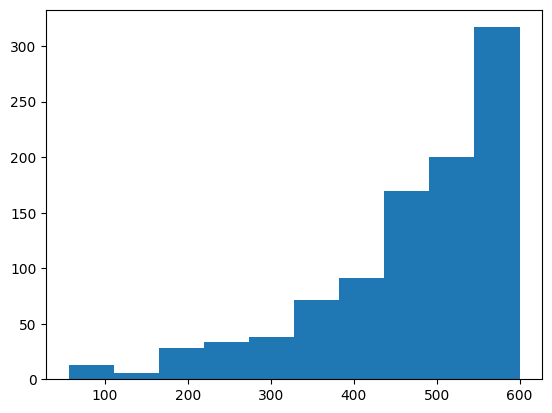

In [4]:
import torch
import os
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.runnables import RunnableLambda
from langchain.schema import Document
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from openai import OpenAI

load_dotenv()

book_path = "books/pan-tadeusz.txt"
# embedding_model_name = "intfloat/multilingual-e5-small"
# embedding_model_name = "intfloat/multilingual-e5-large-instruct"
embedding_model_name = "BAAI/bge-m3"

# === 1. LOADING EMBEDDING MODEL =======================================================================================

embedding_model = HuggingFaceEmbeddings(
    model_name=embedding_model_name,
    model_kwargs={
        "device": "cuda" if torch.cuda.is_available() else "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)


# === 2. LOADING DOCUMENTS AND CREATING VECTOR DATABASE ================================================================

def load_documents(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    # More sophisticated splitting
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=600,  # Optimal for most embeddings
        chunk_overlap=70,
        separators=["\n", ".", " ", ""]  # Try to keep paragraphs together
    )
    splitted_text = text_splitter.create_documents([text])

    for i, doc in enumerate(splitted_text):
        doc.metadata = {
            "source": path,
            "chunk_id": i,
            "length": len(doc.page_content)
        }

    return splitted_text


documents = load_documents(book_path)

lengths = [doc.metadata['length'] for doc in documents]
plt.hist(lengths)